# 11 · Statistical inference and reproducibility

Notebooks 01 to 10 teach *how* to manipulate data with pandas. This notebook asks whether the numbers we
produce are **trustworthy**. It covers four questions:

1. **Is the data what we think it is?** Schema validation.
2. **Can the result be re-derived?** A deterministic pipeline with a provenance manifest.
3. **How uncertain is an estimate?** Interval estimates instead of point estimates.
4. **Is an apparent effect real?** Effect sizes, spurious correlation and multiple comparisons.

A useful property of this project's data is that it is **synthetic with a known null**. Every variable was
drawn independently, as described in `docs/DATA_CARD.md`. Any "discovery" is therefore a false positive, which
makes the data ideal for checking whether a method is honest.

Everything here uses the tested `pandasplayground` package. The methods and references are in `docs/METHODOLOGY.md`.

In [1]:
# Notebook import setup: make the project importable without installing it
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import scripts  # noqa: F401  (adds src/ to the path if the package is not installed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandasplayground import io, schemas, stats
from pandasplayground.pipeline import days_observed, run_pipeline

DATA = PROJECT_ROOT / "data"
EXPORTS = PROJECT_ROOT / "exports"
SEED = 42
pd.set_option("display.precision", 4)

## 1. Validate before analysing

Each dataset has a declarative contract in `src/pandasplayground/schemas.py`. It covers types, nullability,
ranges, allowed values, patterns and cross-column rules. Validation reports **every** violation, not just the first.

In [2]:
reports = {name: schema.validate(io.read(DATA / name)) for name, schema in schemas.RAW_SCHEMAS.items()}
pd.DataFrame(
    [{"dataset": n, "rows": r.n_rows, "passed": r.ok, "issues": len(r.failures)} for n, r in reports.items()]
)

,dataset,rows,passed,issues
0,superstore_sales.csv,10000,True,0
1,bank_loans.xlsx,10000,True,0
2,covid_data.parquet,10000,True,0
3,weather_data.json,10000,True,0


A contract is only useful if it catches problems. Below we corrupt a copy of the loans table the way
real data often goes wrong: an impossible age, a typo in a category, a duplicated ID and a missing value.
Note how the missing value shows up. In pandas, a single `NaN` silently turns an integer column into float,
and the contract reports that change of type.

In [3]:
loans = io.read(DATA / "bank_loans.xlsx")
corrupted = loans.copy()
corrupted.loc[0, "Age"] = 240
corrupted.loc[1, "Loan_Purpose"] = "Hom"
corrupted.loc[2, "Customer_ID"] = corrupted.loc[3, "Customer_ID"]
corrupted.loc[4, "Income"] = np.nan

report = schemas.BANK_LOANS.validate(corrupted)
print(report)

Schema 'bank_loans' on 10,000 rows: FAILED (5 issue(s))
  - [Customer_ID] unique: 2 failing e.g. [1004]
  - [Age] <= 100: 1 failing e.g. [240]
  - [Income] dtype is int (missing values upcast integers to float): 1 failing e.g. ['float64']
  - [Income] not null: 1 failing
  - [Loan_Purpose] in allowed set: 1 failing e.g. ['Hom']


## 2. Re-derive the result, then prove it

The final monthly panel (`exports/final_merged_pipeline.csv`) is rebuilt from the **raw** files. The
content fingerprint of the rebuilt frame must equal the committed export's fingerprint.

In [4]:
result = run_pipeline(write=False)
committed = io.read(EXPORTS / "final_merged_pipeline.csv")

print("rebuilt   :", io.frame_fingerprint(result.frame)[:16])
print("committed :", io.frame_fingerprint(committed.astype(result.frame.dtypes.to_dict()))[:16])
pd.testing.assert_frame_equal(result.frame, committed, check_dtype=False)
print("Identical content. Validation:", result.manifest.validation)

rebuilt   : 52d9d543711dcb70
committed : 52d9d543711dcb70
Identical content. Validation: {'superstore_sales': True, 'covid_data': True, 'final_merged_pipeline': True}


In [5]:
# The manifest records exactly what went in and what came out
m = result.manifest.to_dict()
pd.DataFrame(m["inputs"])[["path", "rows", "sha256"]].assign(sha256=lambda d: d.sha256.str[:12] + "…")

,path,rows,sha256
0,data/superstore_sales.csv,10000,0e8d78a149fb…
1,data/covid_data.parquet,10000,7901354aaa62…


## 3. Report uncertainty, not just a number

Take the average monthly profit margin. A single number hides how much it could vary. We compare two
95% intervals:

- **Student-t**, which assumes the sample mean is approximately normal;
- **BCa bootstrap**, which resamples the data and corrects for bias and skew (Efron, 1987).

In [6]:
panel = result.frame.assign(margin=lambda d: d.profit / d.sales)

t_ci = stats.mean_ci(panel["margin"])
boot_ci = stats.bootstrap_ci(panel["margin"], n_resamples=9_999, seed=SEED)
median_ci = stats.bootstrap_ci(panel["margin"], statistic=np.median, n_resamples=9_999, seed=SEED)

pd.DataFrame([
    {"estimate": "mean margin", **t_ci.as_dict()},
    {"estimate": "mean margin", **boot_ci.as_dict()},
    {"estimate": "median margin", **median_ci.as_dict()},
])

,estimate,point,low,high,level,method
0,mean margin,0.0495,0.0483,0.0506,0.95,student-t
1,mean margin,0.0495,0.0484,0.0506,0.95,bootstrap-BCa
2,median margin,0.0487,0.0471,0.0506,0.95,bootstrap-BCa


The two intervals for the mean nearly coincide because 329 monthly means are close to normal (central limit
theorem). The bootstrap earns its keep on statistics with no simple formula, such as the median.

The generator sets the expected margin to 5%, from `Profit = Sales × (0.05 + 0.05·Z)`. Check whether the
intervals cover it. With real data we never know the truth, so we rely on the method's
coverage guarantee. `tests/test_stats.py` checks that guarantee by simulation.

## 4. Spurious correlation: a confound hiding in the aggregation

The pipeline joins monthly sales to monthly COVID cases. The two daily series were generated
**independently**, so the true correlation is zero. Let us check.

In [7]:
pd.DataFrame([
    {"comparison": "monthly totals, Pearson", **stats.correlation_ci(panel.sales, panel.new_cases).as_dict()},
    {"comparison": "monthly totals, Spearman", **stats.correlation_ci(panel.sales, panel.new_cases, method="spearman").as_dict()},
    {"comparison": "first differences", **stats.differenced_correlation(panel.sales, panel.new_cases).as_dict()},
])

,comparison,point,low,high,level,method
0,"monthly totals, Pearson",0.2566,0.1527,0.3548,0.95,pearson-fisher-z
1,"monthly totals, Spearman",0.1393,0.0317,0.2438,0.95,spearman-fisher-z
2,first differences,0.2536,0.1494,0.3522,0.95,pearson-fisher-z


The correlation is positive and its interval **excludes zero**, even after differencing. For independent
data this is a false finding, so something in the construction of the panel must be creating it.

Both columns are monthly *sums* of daily values. A 31-day month accumulates more sales **and** more cases
than a 28-day month. The final month, May 2047, is only partly observed because the series ends mid-month.
Calendar length is a common cause of both totals: a **confounder**.

In [8]:
days = days_observed(io.read(DATA / "superstore_sales.csv"), io.read(DATA / "covid_data.parquet"))
panel_d = panel.merge(days, on="month", validate="one_to_one").assign(
    sales_per_day=lambda d: d.sales / d.store_days,
    cases_per_day=lambda d: d.new_cases / d.covid_days,
)
print(days.store_days.value_counts().sort_index().to_dict(), "(days observed per month: number of months)")

pd.DataFrame([
    {"relationship": "sales total ~ days in month", **stats.correlation_ci(panel_d.sales, panel_d.store_days).as_dict()},
    {"relationship": "cases total ~ days in month", **stats.correlation_ci(panel_d.new_cases, panel_d.covid_days).as_dict()},
    {"relationship": "sales per day ~ cases per day", **stats.correlation_ci(panel_d.sales_per_day, panel_d.cases_per_day).as_dict()},
])

{18: 1, 28: 21, 29: 7, 30: 109, 31: 191} (days observed per month: number of months)


,relationship,point,low,high,level,method
0,sales total ~ days in month,0.2816,0.1789,0.3782,0.95,pearson-fisher-z
1,cases total ~ days in month,0.9754,0.9696,0.9802,0.95,pearson-fisher-z
2,sales per day ~ cases per day,-0.0882,-0.1945,0.0201,0.95,pearson-fisher-z


Case totals are almost entirely explained by month length. Once both series are expressed **per observed
day**, the interval spans zero, which is the correct answer.

The lesson: aggregation choices can create associations. Before interpreting a correlation between
aggregated series, ask what else scales both. Common suspects are exposure, population, calendar length and
the number of reporting units.

Differencing addresses a different problem: shared **trends**. Two independent random walks look strongly
correlated in levels (Granger & Newbold, 1974). The simulation below shows that differencing restores the
correct answer in that case.

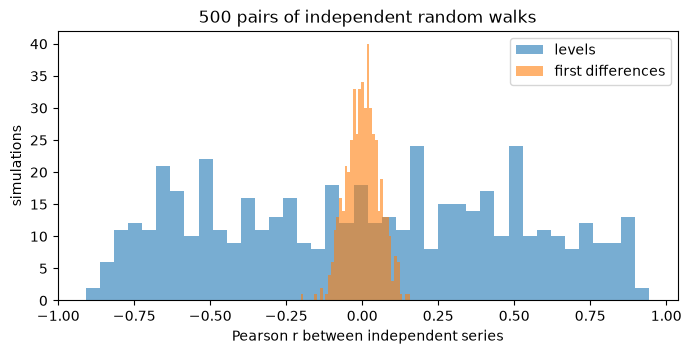

|r| > 0.5 in levels: 42%   after differencing: 0%


In [9]:
rng = np.random.default_rng(SEED)
level_r, diff_r = [], []
for _ in range(500):
    a, b = rng.normal(size=(2, 329)).cumsum(axis=1)  # two independent random walks
    level_r.append(stats.correlation_ci(a, b).point)
    diff_r.append(stats.differenced_correlation(a, b).point)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(level_r, bins=40, alpha=0.6, label="levels")
ax.hist(diff_r, bins=40, alpha=0.6, label="first differences")
ax.set(xlabel="Pearson r between independent series", ylabel="simulations",
       title="500 pairs of independent random walks")
ax.legend()
plt.show()

print(f"|r| > 0.5 in levels: {np.mean(np.abs(level_r) > 0.5):.0%}   after differencing: {np.mean(np.abs(diff_r) > 0.5):.0%}")

## 5. Effect sizes: significant is not the same as important

Does loan approval depend on purpose? A chi-square test answers "is there *any* dependence?". Cramér's V
answers "how much?". Wilson intervals show each group's uncertainty.

chi2 = 7.50, dof = 5, p = 0.186, Cramér's V = 0.016


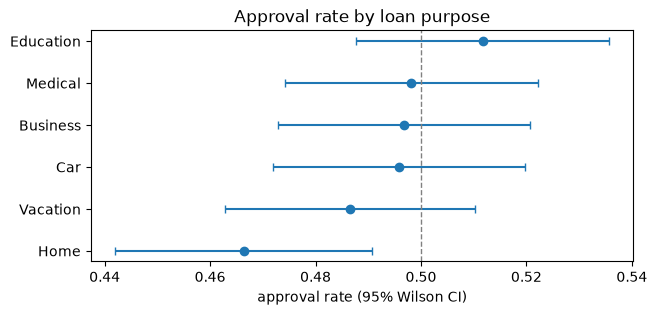

In [10]:
chi = stats.chi2_independence(loans, "Loan_Purpose", "Approved")
print(f"chi2 = {chi.statistic:.2f}, dof = {chi.extra['dof']}, p = {chi.p_value:.3f}, Cramér's V = {chi.effect_size:.3f}")

rows = []
for purpose, g in loans.groupby("Loan_Purpose"):
    k = int((g.Approved == "Yes").sum())
    rows.append({"purpose": purpose, "n": len(g), **stats.proportion_ci(k, len(g)).as_dict()})
rates = pd.DataFrame(rows).sort_values("point")

fig, ax = plt.subplots(figsize=(7, 3))
ax.errorbar(rates.point, rates.purpose, xerr=[rates.point - rates.low, rates.high - rates.point], fmt="o", capsize=3)
ax.axvline(0.5, ls="--", c="grey", lw=1)
ax.set(xlabel="approval rate (95% Wilson CI)", title="Approval rate by loan purpose")
plt.show()

In [11]:
# Income of approved vs rejected applicants: permutation test and Welch's t, both with Hedges' g
approved, rejected = loans.loc[loans.Approved == "Yes", "Income"], loans.loc[loans.Approved == "No", "Income"]
pd.DataFrame([
    stats.permutation_test_means(approved, rejected, n_resamples=9_999, seed=SEED).as_dict(),
    stats.welch_t_test(approved, rejected).as_dict(),
])[["test", "statistic", "p_value", "effect_size", "effect_size_name"]]

,test,statistic,p_value,effect_size,effect_size_name
0,permutation (difference in means),200.8335,0.7888,0.0055,hedges_g
1,welch t-test,0.2769,0.7818,0.0055,hedges_g


A Hedges' g near 0.01 is negligible whatever the p-value says. With very large samples, trivially small
differences become "significant". Always read the effect size first.

## 6. Multiple comparisons

A common analysis runs many subgroup tests and reports the "significant" ones. Here we compare the income of
approved and rejected applicants within every **purpose × region × age-band** cell. There are 96 tests on data
where the true effect is zero everywhere.

In [12]:
# The regional workbook's sheets are copies of one table (see DATA_CARD.md), so testing across them would
# repeat the same customers. Instead, assign each customer one region at random to form independent cells.
rng = np.random.default_rng(SEED)
cells = loans.assign(
    Region=rng.choice(schemas.LOAN_REGIONS, len(loans)),
    Age_Band=pd.cut(loans.Age, [20, 32, 43, 54, 65], right=False).astype(str),
)

tests = []
for key, g in cells.groupby(["Loan_Purpose", "Region", "Age_Band"]):
    res = stats.welch_t_test(g.loc[g.Approved == "Yes", "Income"], g.loc[g.Approved == "No", "Income"])
    tests.append({"cell": " / ".join(key), "n": len(g), "p": res.p_value, "g": res.effect_size})
tests = pd.DataFrame(tests)
tests["p_bh"] = stats.adjust_pvalues(tests.p, "bh")
tests["p_holm"] = stats.adjust_pvalues(tests.p, "holm")

print(f"{len(tests)} tests on data with no true effect")
print(f"  raw p < 0.05          : {(tests.p < 0.05).sum()} 'discoveries' (expected about {0.05 * len(tests):.1f} by chance)")
print(f"  BH-adjusted p < 0.05  : {(tests.p_bh < 0.05).sum()}")
print(f"  Holm-adjusted p < 0.05: {(tests.p_holm < 0.05).sum()}")
tests.sort_values("p").head(5)

96 tests on data with no true effect
  raw p < 0.05          : 8 'discoveries' (expected about 4.8 by chance)
  BH-adjusted p < 0.05  : 0
  Holm-adjusted p < 0.05: 0


,cell,n,p,g,p_bh,p_holm
32,"Education / East / [20, 32)",96,0.0017,0.6500,0.1648,0.1648
74,"Medical / South / [43, 54)",114,0.0095,-0.4937,0.4547,0.8998
88,"Vacation / South / [20, 32)",100,0.0149,-0.5093,0.4773,1.0000
70,"Medical / North / [43, 54)",80,0.0220,-0.5180,0.4892,1.0000
55,"Home / North / [54, 65)",104,0.0270,0.4404,0.4892,1.0000


Without correction a handful of cells look "significant", and each would make a tempting headline.
After controlling the false discovery rate (Benjamini-Hochberg) or the family-wise error rate (Holm), the
spurious findings disappear. That is the correct outcome for data with no signal.

## Summary

| Question | Tool | Takeaway |
| --- | --- | --- |
| Is the data valid? | `schemas.*.validate` | Contracts catch corrupt values before they reach an analysis. |
| Can the result be re-derived? | `run_pipeline` + manifest | The export is rebuilt from raw data with an identical fingerprint. CI enforces this. |
| How uncertain is it? | `bootstrap_ci`, `mean_ci`, `proportion_ci` | Report intervals. Prefer BCa for statistics without a closed form. |
| Is the effect real? | effect sizes, `days_observed`, `differenced_correlation`, `adjust_pvalues` | Check magnitude, look for confounders created by aggregation, remove shared trends, correct for multiplicity. |

**Exercises**

1. Add a rule to `schemas.SUPERSTORE` requiring `Profit <= Sales`, then run `pandasplayground validate`.
2. Re-run section 6 with 500 cells. How many raw "discoveries" appear, and how many survive BH?
3. Inject a real effect by making approval more likely for incomes above 100k. How large must it be for
   the chi-square test to detect it reliably at *n* = 10,000?